<a href="https://colab.research.google.com/github/minjeon99/ESAA-10th-OB/blob/Week12/w12_mon_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4. **합성곱 신경망(CNN)**

## **04 위성 이미지 분류**

### 1. 텐서플로 데이터셋 로드
- EuroSAT: 인공위성에서 지표면을 촬영한 이미지와 토지이용분류 값을 정리
  - 27000장의 사진, 10개의 분류

In [1]:
import tensorflow as tf
import numpy as np
import json
import matplotlib.pyplot as plt

# Tensorflow Datasets 활용
import tensorflow_datasets as tfds

`load()`로 EuroSAT 데이터셋 불러오기
- `(훈련, 검증), 메타 정보`
- `info`(메타 정보): `with_info = True` 옵션으로 설정

In [ ]:
# EuroSAT 위성 사진 데이터셋 로드
DATA_DIR = "dataset/"

(train_ds, valid_ds), info = tfds.load('eurosat/rgb', split=['train[:80%]', 'train[80%:]'],
                                       shuffle_files=True,
                                       as_supervised=True,
                                       with_info=True,
                                       data_dir=DATA_DIR)
print(train_ds, '\n', valid_ds)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

- URL을 통해 데이터 다운
- `data_dir` 옵션: 파일 저장 위치 지정
- train 데이터만 제공 → 80:20으로 train/valid 분할 저장
- 이미지 shape: (64. 64. 3)

In [ ]:
# 메타 데이터 확인
print(info)

- EuroSAT의 2가지 유형 중 JPEG 이미지로 인코딩한 RGB 데이터셋 다운로드

In [ ]:
# 데이터 확인
tfds.show_examples(train_ds, info)

In [ ]:
# as_dataframe 사용하여 샘플 출력
tfds.as_dataframe(valid_ds.take(10), info)

In [ ]:
# 목표 클래스의 개수
NUM_CLASSES = info.features['label'].num_classes
print(NUM_CLASSES)

- 토지이용분류에 해당하는 정답 클래스 개수: 10개
  - 0: 경작지(AnnualCrop)
  - 9: 바다/호수(SeaLake)

In [ ]:
# 숫자 레이블을 활용해 문자열 메타 데이터로 변환
print(info.features['label'].int2str(6))

### 2. 데이터 전처리
- 텐서플로 데이터셋 - 데이터 전처리 과정이 매우 쉽다는 장점
- 전처리 함수 `preprocess_data`
  - 텐서플로 연산 - `float32` 숫자 값을 사용
    - `cast` 함수로 자료형 변환
  - 입력 이미지: 0~255 범위 픽셀 값 → 255로 나눠서 정규화
- `map` 함수: 사용자 정의 함수를 매핑하여 텐서플로 데이터셋에 적용하는 메소드
  - `num_parallel_calls = AUTOTUNE`: 텐서플로 병렬연산 처리를 자동으로 최적화

  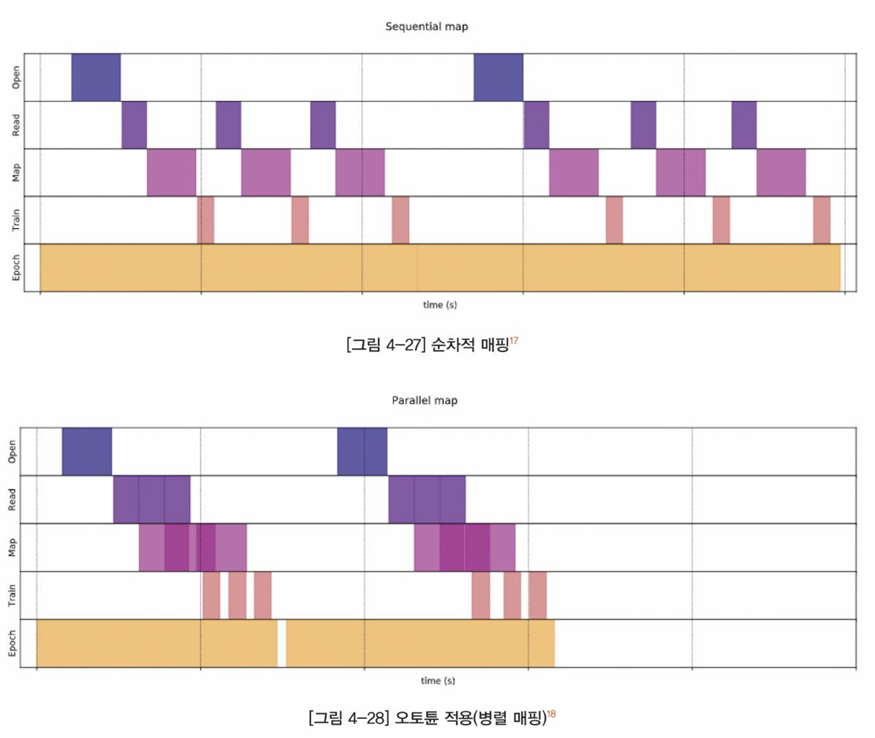
- 정규화 변환을 마친 데이터셋에 `shuffle()` 메소드 적용하여 순서 랜덤하게 섞기
  - 모델의 일반화된 성능을 높이기 위해 훈련 데이터셋에서 미니 배치를 생성할 때 입력 순서에 무작위성 부여
- `BUFFER_SIZE=1000`, `BATCH_SIZE=64`: 1000개의 데이터 가져와서 섞고, 64개의 데이터를 랜덤하게 선택해서 하나의 배치 구성
  - 64개가 추출되어 미니 배치를 구성하고 학습에 사용되면, 다시 64개가 버퍼에 추가되어 항상 1000개 유지
- `prefetch()`: 모델이 훈련을 진행하는 동안 다음에 입력할 데이터를 불러와서 미리 전처리 → 병렬 처리로 모델 훈련 시간 단축

In [11]:
# 데이터 전처리 파이프라인
BATCH_SIZE = 64
BUFFER_SIZE = 1000

def preprocess_data(image, label):
  image = tf.cast(image, tf.float32)/255. # 0~1 정규화, float32 변환
  return image, label

train_data = train_ds.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
valid_data = valid_ds.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)

train_data = train_data.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
valid_data = valid_data.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

- `shuffle()`의 `buffer_size` 파라미터
  - 데이터셋이 작은 경우: 전체 데이터셋 개수로 지정하는 것이 무작위성 확보에 유리
  - 데이터셋이 큰 경우: 시스템상의 메모리에 전부 올릴 수 없는 경우 `buffer_size=1000`으로 지정하는 것이 일반적
- 훈련 데이터셋: 모델 가중치 학습에 사용되기 때문에 순서를 랜덤하게 섞을 필요 ⭕
- 검증 데이터셋: 평가 목적에 활용되기 때문에 순서에 큰 의미 X ⇒ shuffle 함수 사용 ❌

### 3. 모델 훈련 및 검증
배치 정규화, 합성곱, 풀링 레이어로 구성된 유닛을 2개 연결 → Dense 레이어와 Dropouto으로 구성된 최종 분류기 딥러닝 모델

In [12]:
# Sequential_API를 사용하여 샘플 모델 생성
def build_model():
  model = tf.keras.Sequential([
      # Convolution layer
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
      tf.keras.layers.MaxPooling2D((2,2)),

      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
      tf.keras.layers.MaxPooling2D((2,2)),

      # Classifier Output layer
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(128, activation='relu'),
      tf.keras.layers.Dropout(0.3),
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.Dropout(0.3),
      tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
  ])

  return model

model = build_model()

- 예측 클래스가 10개인 다중 분류 문제
  - loss function: sparse_categorical_crossentropy
  - metrics: accuracy

In [18]:
# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
history = model.fit(train_data, validation_data=valid_data, epochs=50)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 85s 39ms/step - accuracy: 0.3146 - loss: 2.0136 - val_accuracy: 0.4459 - val_loss: 1.6826
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4723 - loss: 1.4785 - val_accuracy: 0.6722 - val_loss: 1.0222
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5120 - loss: 1.3318 - val_accuracy: 0.6626 - val_loss: 1.0347
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5539 - loss: 1.2203 - val_accuracy: 0.6883 - val_loss: 0.8910
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5837 - loss: 1.1427 - val_accuracy: 0.7435 - val_loss: 0.8123
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6385 - loss: 1.0238 - val_accuracy: 0.7669 - val_loss: 0.7224
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6501 - loss: 0.9792 - val_accuracy: 0.7770 - val_loss: 0.7086
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6866 - loss: 0.8956 - val_acc

In [19]:
# 손실함수, 정확도 그래프 그리기

def plot_loss_acc(history, epoch):

    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(range(1, epoch + 1), loss, label='Training')
    axes[0].plot(range(1, epoch + 1), val_loss, label='Validation')
    axes[0].legend(loc='best')
    axes[0].set_title('Loss')

    axes[1].plot(range(1, epoch + 1), acc, label='Training')
    axes[1].plot(range(1, epoch + 1), val_acc, label='Validation')
    axes[1].legend(loc='best')
    axes[1].set_title('Accuracy')

    plt.show()

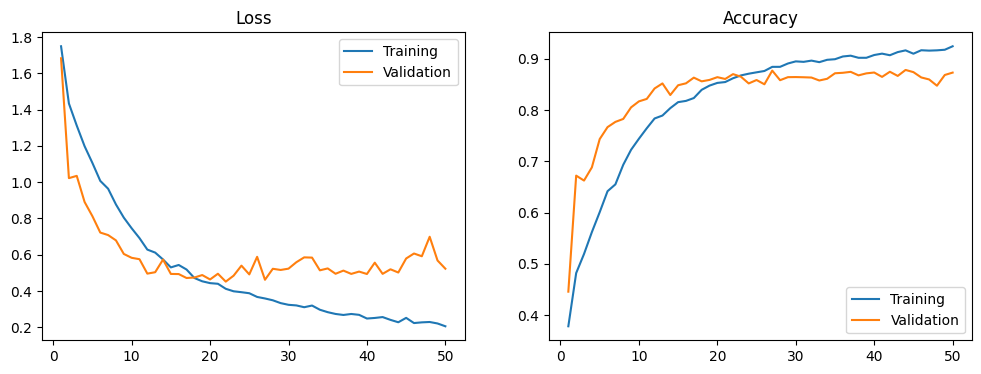

In [20]:
# 손실함수, 정확도 그래프
plot_loss_acc(history, 50)

- 10 epoch까지는 빠른 속도로 훈련이 진행되면서 손실함수가 급격하게 감소
- 이후로는 검증셋에 대한 손실함수가 더 이상 줄어들지 않으면서 과대적합 경향을 보임

### 4. 데이터 증강(Data Augmentation)
앞선 모델에서 과대적합 해소 기법인 배치 정규화, Dropout을 적용했음에도 과대적합 발생

➡️ **데이터 증강(Data Augmentation)** 기법: 이미지 데이터에 여러 변형을 주어서 훈련 데이터의 다양성 확보
- 과대적합 해소
- 모델의 일반화된 Robust한 성능 확보
- 새로운 데이터에 대한 예측력 강화

Text(0.5, 1.0, 'River')

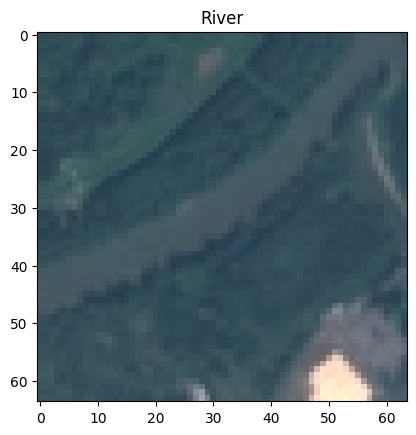

In [21]:
# 샘플 이미지
image_batch, label_batch = next(iter(train_data.take(1)))

image = image_batch[0]
label = label_batch[0].numpy()

plt.imshow(image)
plt.title(info.features['label'].int2str(label))

In [24]:
# 데이터 증강 전후를 비교하는 시각화 함수 정의
def plot_augmentation(original, augmented):

  fig, axes = plt.subplots(1,2, figsize=(12,4))

  axes[0].imshow(original)
  axes[0].set_title('Original')

  axes[1].imshow(augmented)
  axes[1].set_title('Augmented')

  plt.show()

- `tf.image` 모듈의 `flip_left_right`: 이미지 좌우 방향 뒤집기

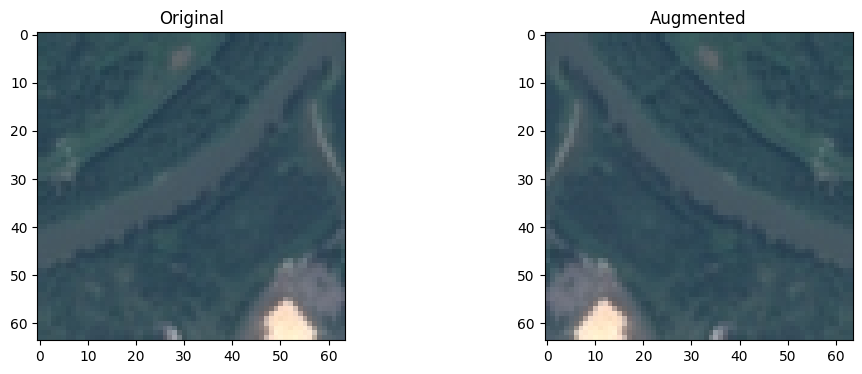

In [25]:
# 좌우 뒤집기
lr_flip = tf.image.flip_left_right(image)
plot_augmentation(image, lr_flip)

- `flip_up_down`: 이미지 상하 방향 뒤집기

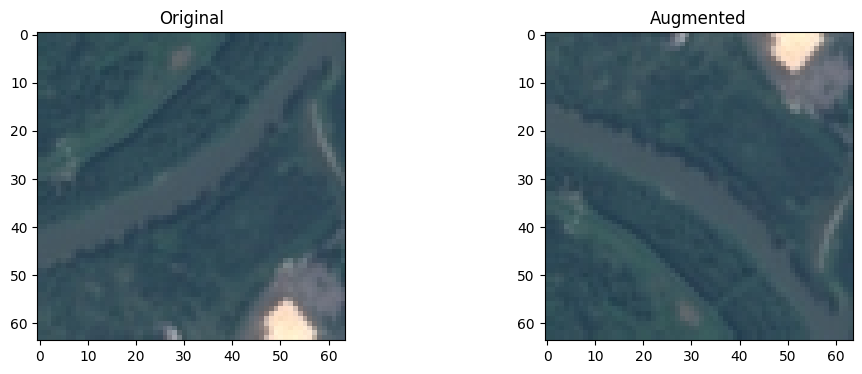

In [26]:
# 상하 뒤집기
ud_flip = tf.image.flip_up_down(image)
plot_augmentation(image, ud_flip)

- `rot90`: 이미지 반시계 방향 90도 회전

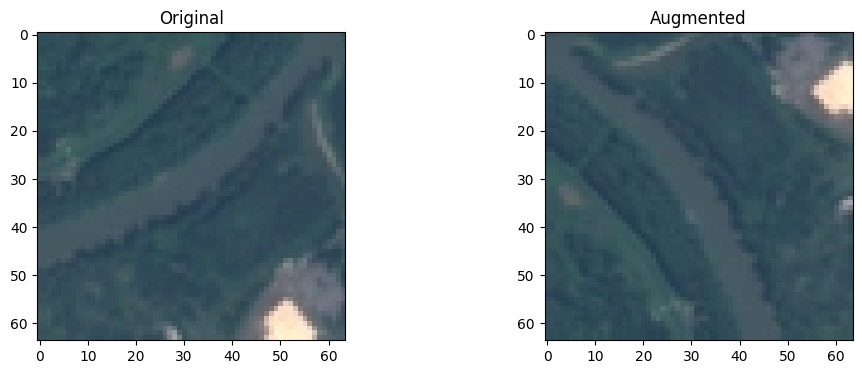

In [28]:
# 회전
rotate90 = tf.image.rot90(image)
plot_augmentation(image, rotate90)

- `transpose`: 이미지 텐서 행렬의 행-열 위치 바꾸기(행렬 도치)

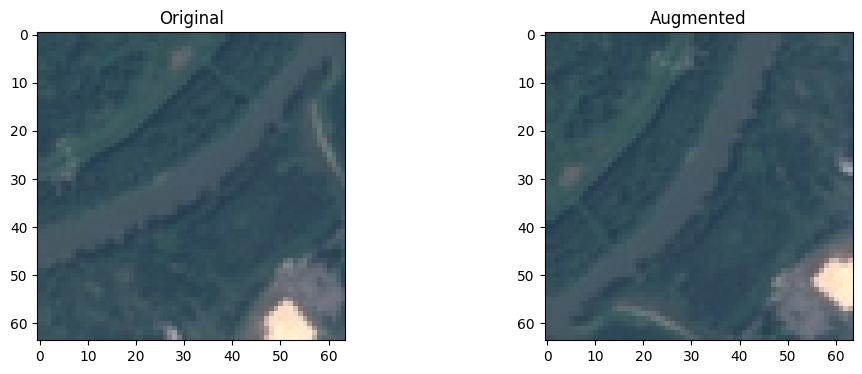

In [29]:
# transpose
transpose = tf.image.transpose(image)
plot_augmentation(image, transpose)

- `central_crop`: 이미지의 중심에서 일정 부분 자르기

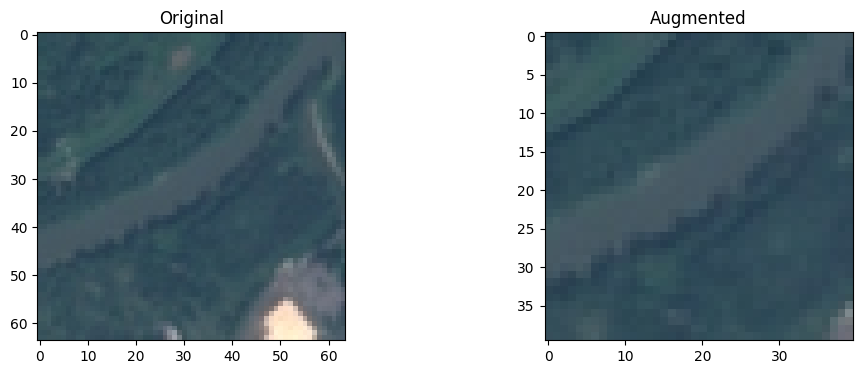

In [30]:
# 이미지 자르기1
crop1 = tf.image.central_crop(image, central_fraction=0.6)
plot_augmentation(image, crop1)

- `resize_with_crop_or_pad`: 원본 이미지의 크기 키우기
- `random_crop`: randomly crop
  - 원본 크기와 같게 지정 →  원본 이미지가 상하좌우 랜덤 방향으로 shift 이동

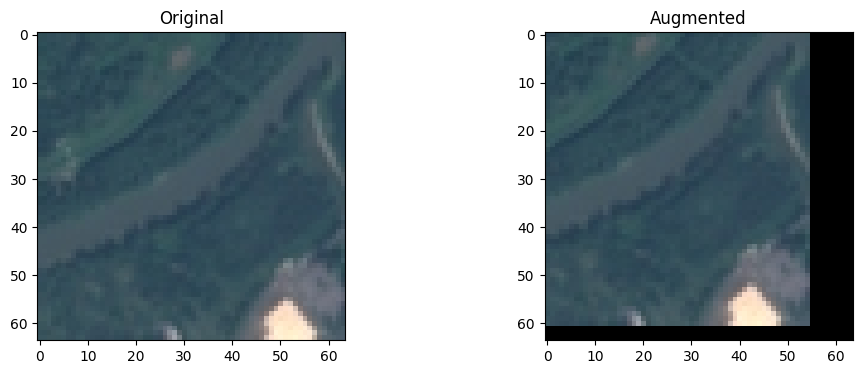

In [31]:
# 이미지 자르기2
img = tf.image.resize_with_crop_or_pad(image, 64+20, 64+20) # 사이즈 키우기
crop2 = tf.image.random_crop(img, size=[64,64,3])
plot_augmentation(image, crop2)

- `adjust_brightness`: 이미지 밝기 조정

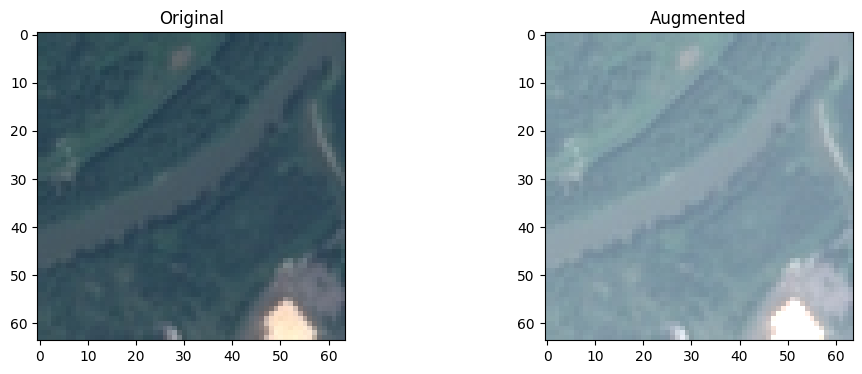

In [32]:
# 이미지 밝기
brightness = tf.image.adjust_brightness(image, delta=0.3)
plot_augmentation(image, brightness)

- `adjust_saturation`: 이미지 채도 변경

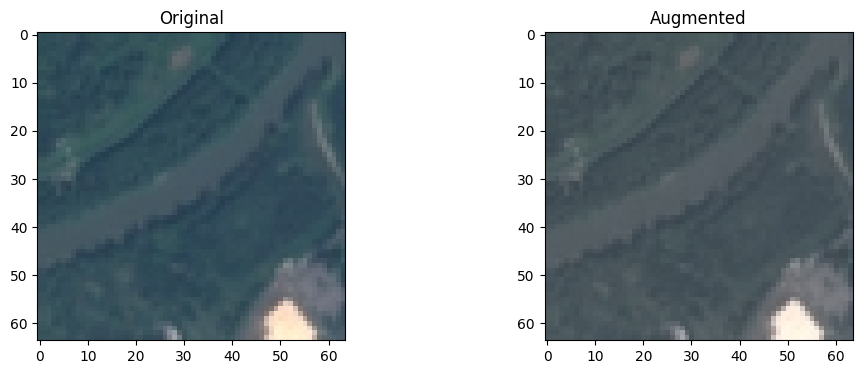

In [35]:
# 이미지 채도
saturation = tf.image.adjust_saturation(image, saturation_factor=0.5)
plot_augmentation(image, saturation)

- `adjust_contrast`: 이미지 대비 조정

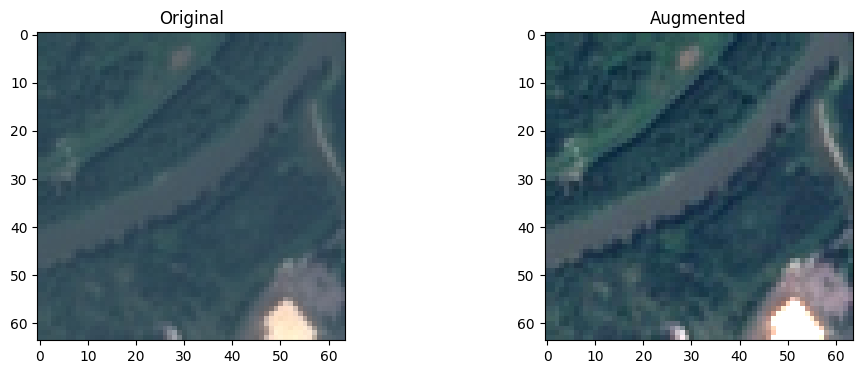

In [36]:
# 이미지 대비
contrast = tf.image.adjust_contrast(image, contrast_factor=2)
plot_augmentation(image, contrast)

- 앞서 다룬 기법 중 몇가지를 선택하여 데이터 증강 및 전처리를 수행하는 함수 정의
  - 이미지 증강 효과에 랜덤성을 부여하기 위해 `random_`으로 시작하는 함수 적용
  - `map` 함수로 원본 데이터셋에 적용
  - `shuffle`, `batch` 함수 등으로 미니 배치 만들기

In [40]:
# 이미지 증강 전처리
def data_augmentation(image, label):
  image = tf.image.random_flip_left_right(image) # 좌우 반전
  image = tf.image.random_flip_up_down(image) # 상하 반전
  image = tf.image.random_brightness(image, max_delta=0.3) # 밝기 변화
  image = tf.image.random_crop(image, size=[64,64,3])

  image = tf.cast(image, tf.float32)/255. # 0~1 정규화

  return image, label

train_aug = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
valid_aug = valid_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)

train_aug = train_aug.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
valid_aug = valid_aug.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print(train_aug)
print(valid_aug)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


In [41]:
# 모델 생성
aug_model = build_model()

# 모델 컴파일
aug_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
aug_history = aug_model.fit(train_aug, validation_data=valid_aug, epochs=50)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.2448 - loss: 2.2085 - val_accuracy: 0.3565 - val_loss: 1.6817
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3856 - loss: 1.5981 - val_accuracy: 0.4526 - val_loss: 1.4004
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4604 - loss: 1.4045 - val_accuracy: 0.6063 - val_loss: 1.1307
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5046 - loss: 1.3008 - val_accuracy: 0.6089 - val_loss: 1.0407
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5304 - loss: 1.2556 - val_accuracy: 0.6078 - val_loss: 1.1203
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5591 - loss: 1.1589 - val_accuracy: 0.6598 - val_loss: 0.9756
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5874 - loss: 1.1081 - val_accuracy: 0.6987 - val_loss: 0.8818
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6159 - loss: 1.0269 - val_acc

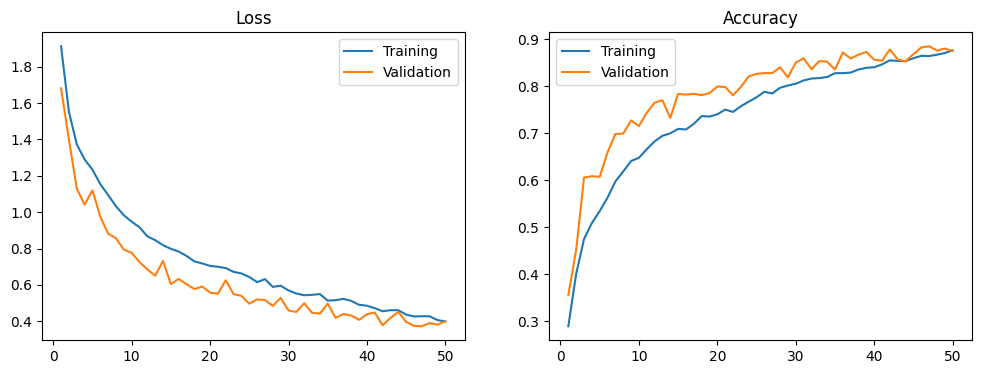

In [42]:
# 손실함수, 정확도 그래프
plot_loss_acc(aug_history, 50)

- 훈련/검증 셋에 대한 손실함수가 50 epoch 동안 계속 줄어들고 정확도는 우상향하면서 개선

  ➡️ 과대적합 문제가 상당히 해소됨
  - 여전히 훈련 셋보다 검증 셋에 대한 손실함수 그래프가 더 낮음 → 모델을 더 훈련시키면 성능을 개선시킬 여지 ⭕

### 5. ResNet 사전 학습 모델
- ResNet: 이미지넷 경진 대회에서 우승한 모델, 우수한 성능
- 사전에 방대한 이미지로 훈련 받은 딥러닝 모델의 구조와 가중치를 그대로 가져오고,
  
  모델의 끝단에 위치한 Top 층에 위성 이미지를 분류할 수 있는 최종 분류기를 추가하는 방식으로 모델 구성

  ➡️ **전이 학습(Transfer Learning)**
- 케라스에서 모델 인스턴스 직접 불러오기
  - ResNet50V2 버전 사용
- `input_shape`: 사용하는 위성 이미지 크기 지정
  - ResNet 모델의 입력 크기: (224, 224, 3)이지만, 케라스에서 이미지 크기를 우리가 지정한 크키고 맞춰서 줄여줌
- `classes`: 분류하려는 클래스 레이블의 개수(10) 지정
- ⭐`include_top = False`⭐: 기존 모델의 Top 층 제거
  - 기존 ResNet 모델의 Top 층은 이미지넷 경진 대회에 맞는 분류기이므로 제거해야 함

  ➡️ 우리가 해결하려는 문제에 맞는 최종 분류기📍를 대체해서 추가

In [48]:
# Pre-trained 모델을 사전 학습된 가중치와 함께 가져오기
from tensorflow.keras.applications import ResNet50V2

pre_trained_base = ResNet50V2(include_top=False, weights='imagenet', input_shape=[64,64,3])

# 사전 학습된 가중치를 업데이트되지 않도록 설정
pre_trained_base.trainable = False

# 모델 구조 시각화
from tensorflow.keras.utils import plot_model
plot_model(pre_trained_base, show_shapes=True, show_layer_names=True, to_file='resnet50.png')

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.537852 to fit



In [50]:
# Top 층에 Classifier 추가

def build_trainsfer_classifier():
  model = tf.keras.Sequential([
      # Pre-trained Base
      pre_trained_base,
      # Classifier 출력층
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(128, activation='relu'),
      tf.keras.layers.Dropout(0,3),
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.Dropout(0.3),
      tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
  ])

  return model

# 모델 구조
tc_model = build_trainsfer_classifier()
tc_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 2, 2, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,622,410 (93.93 MB)

 Trainable params: 1,057,610 (4.03 MB)

 Non-trainable params: 23,564,800 (89.89 MB)